In [3]:
# ============================================
# 1. IMPORT LIBRARIES
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [6]:
df = pd.read_csv("/content/creditcard.csv", on_bad_lines='warn')

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (360498, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338320769942518,0.462387777762292,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0.0,1.191857,0.266151,0.16648,0.448154,0.0600176492822243,-0.0823608088155687,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198133318193,1.80049938079263,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.0103088796030823,1.24720316752486,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193377311653,0.0959214624684256,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [7]:
# ============================================
# 3. BASIC DATASET INFORMATION
# ============================================

print("Shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nClass distribution:")
print(df["Class"].value_counts())

print("\nClass distribution (%):")
print(df["Class"].value_counts(normalize=True) * 100)

Shape: (360498, 31)

Column names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Missing values:
850

Class distribution:
Class
0.0    359743
1.0       668
Name: count, dtype: int64

Class distribution (%):
Class
0.0    99.814656
1.0     0.185344
Name: proportion, dtype: float64


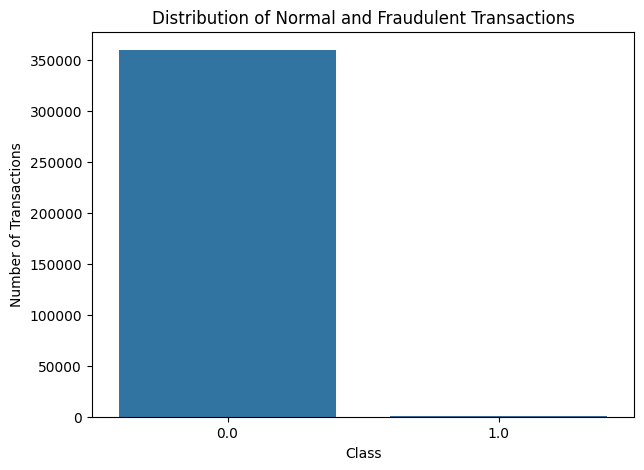

In [8]:
# ============================================
# 4. CLASS DISTRIBUTION
# ============================================

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Class")

plt.title("Distribution of Normal and Fraudulent Transactions")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")

plt.show()

In [9]:
# ============================================
# 5. SEPARATE FEATURES AND TARGET
# ============================================

X = df.drop("Class", axis=1)
y = df["Class"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (360498, 30)
Target shape: (360498,)


In [11]:
# ============================================
# 6. FEATURE SCALING
# ============================================

# Convert all columns in X to numeric, coercing errors to NaN
# This handles the 'could not convert string to float' error
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

# Drop rows where any NaN values are present (introduced by coercion or originally present)
# This ensures all data is numeric before scaling
initial_rows = X.shape[0]
X.dropna(inplace=True)
y = y[X.index] # Align y with the dropped rows in X
rows_dropped = initial_rows - X.shape[0]
if rows_dropped > 0:
    print(f"Dropped {rows_dropped} rows containing non-numeric or missing values.")

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled data shape:", X_scaled.shape)

Dropped 83 rows containing non-numeric or missing values.
Scaled data shape: (360415, 30)


In [13]:
# ============================================
# 7. TRAIN-TEST SPLIT
# ============================================

# Get a boolean mask for non-NaN values in y
non_nan_mask_y = ~y.isna()

# Filter X_scaled (numpy array) and y (pandas Series) using the mask
X_clean_for_split = X_scaled[non_nan_mask_y]
y_clean_for_split = y[non_nan_mask_y]

# Now perform the train-test split with the cleaned data
X_train, X_test, y_train, y_test = train_test_split(
    X_clean_for_split,
    y_clean_for_split,
    test_size=0.20,
    random_state=42,
    stratify=y_clean_for_split # stratify by the cleaned target variable
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (288328, 30)
Testing set: (72083, 30)


In [14]:
# ============================================
# 8. SELECT ONLY NORMAL TRANSACTIONS
# ============================================

X_train_normal = X_train[y_train.values == 0]

print("Normal transactions used for training:",
      X_train_normal.shape)

print("Fraudulent transactions in training:",
      np.sum(y_train.values == 1))

Normal transactions used for training: (287794, 30)
Fraudulent transactions in training: 534


In [15]:
# ============================================
# 9. BUILD AUTOENCODER
# ============================================

input_dim = X_train_normal.shape[1]

# Input layer
input_layer = Input(shape=(input_dim,))

# Encoder
encoder = Dense(32, activation="relu")(input_layer)
encoder = Dropout(0.2)(encoder)

encoder = Dense(16, activation="relu")(encoder)

# Latent representation
latent = Dense(8, activation="relu", name="latent_space")(encoder)

# Decoder
decoder = Dense(16, activation="relu")(latent)
decoder = Dense(32, activation="relu")(decoder)

# Output layer
output_layer = Dense(input_dim, activation="linear")(decoder)

# Complete autoencoder
autoencoder = Model(input_layer, output_layer)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (Dense)            │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 30)             │           990 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,334 (13.02 KB)

 Trainable params: 3,334 (13.02 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# ============================================
# 11. TRAIN AUTOENCODER
# ============================================

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Compile the model before training
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

history = autoencoder.fit(
    X_train_normal,
    X_train_normal,
    epochs=50,
    batch_size=256,
    validation_split=0.20,
    shuffle=True,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
900/900 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.6552 - val_loss: 0.5194
Epoch 2/50
900/900 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.4973 - val_loss: 0.4356
Epoch 3/50
900/900 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.4500 - val_loss: 0.3960
Epoch 4/50
900/900 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.4203 - val_loss: 0.3651
Epoch 5/50
900/900 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.4018 - val_loss: 0.3467
Epoch 6/50
900/900 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.3895 - val_loss: 0.3344
Epoch 7/50
900/900 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.3798 - val_loss: 0.3256
Epoch 8/50
900/900 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.3724 - val_loss: 0.3114
Epoch 9/50
900/900 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.3643 - val_loss: 0.3025
Epoch 10/50
900/900 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.3584 - val_loss: 0.2952
Epoch 11/50
900/900 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.3542 - val_loss: 0.2918
Epoch 12/50
900/900 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step

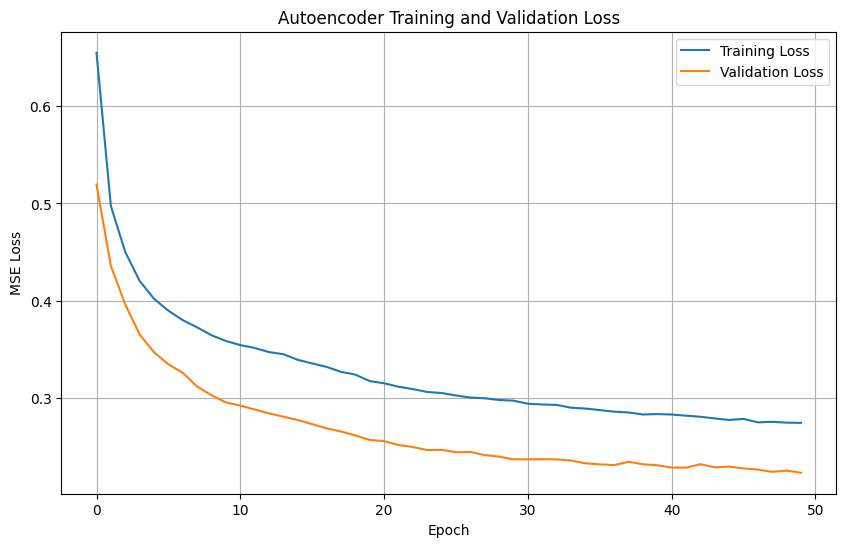

In [18]:
# ============================================
# 12. TRAINING LOSS
# ============================================

plt.figure(figsize=(10, 6))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Autoencoder Training and Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

In [19]:
# ============================================
# 13. RECONSTRUCTION ERROR
# ============================================

X_train_pred = autoencoder.predict(
    X_train_normal,
    verbose=0
)

train_reconstruction_error = np.mean(
    np.square(X_train_normal - X_train_pred),
    axis=1
)

print("Mean reconstruction error:",
      np.mean(train_reconstruction_error))

print("Maximum reconstruction error:",
      np.max(train_reconstruction_error))

Mean reconstruction error: 0.216653898883005
Maximum reconstruction error: 43.710991601922004


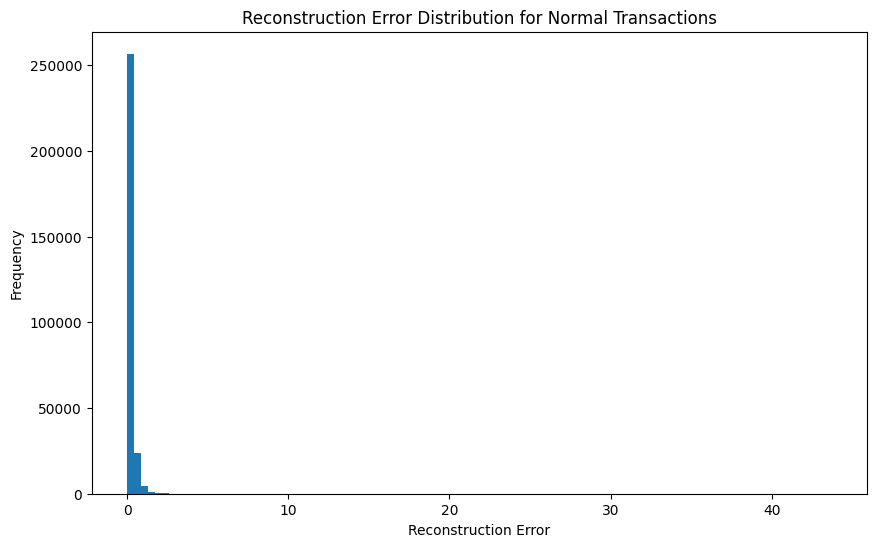

In [20]:
# ============================================
# 14. RECONSTRUCTION ERROR DISTRIBUTION
# ============================================

plt.figure(figsize=(10, 6))

plt.hist(
    train_reconstruction_error,
    bins=100
)

plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")
plt.title("Reconstruction Error Distribution for Normal Transactions")

plt.show()

In [21]:
# ============================================
# 15. SELECT ANOMALY THRESHOLD
# ============================================

threshold = np.percentile(
    train_reconstruction_error,
    95
)

print("Anomaly Detection Threshold:", threshold)

Anomaly Detection Threshold: 0.6479888150993101


In [22]:
# ============================================
# 16. TEST RECONSTRUCTION ERROR
# ============================================

X_test_pred = autoencoder.predict(
    X_test,
    verbose=0
)

test_reconstruction_error = np.mean(
    np.square(X_test - X_test_pred),
    axis=1
)

print("Test reconstruction error calculated.")

Test reconstruction error calculated.


In [23]:
# ============================================
# 17. ANOMALY DETECTION
# ============================================

y_pred = (
    test_reconstruction_error > threshold
).astype(int)

print("Number of predicted anomalies:",
      np.sum(y_pred))

print("Actual fraudulent transactions:",
      np.sum(y_test.values))

Number of predicted anomalies: 3765
Actual fraudulent transactions: 134.0


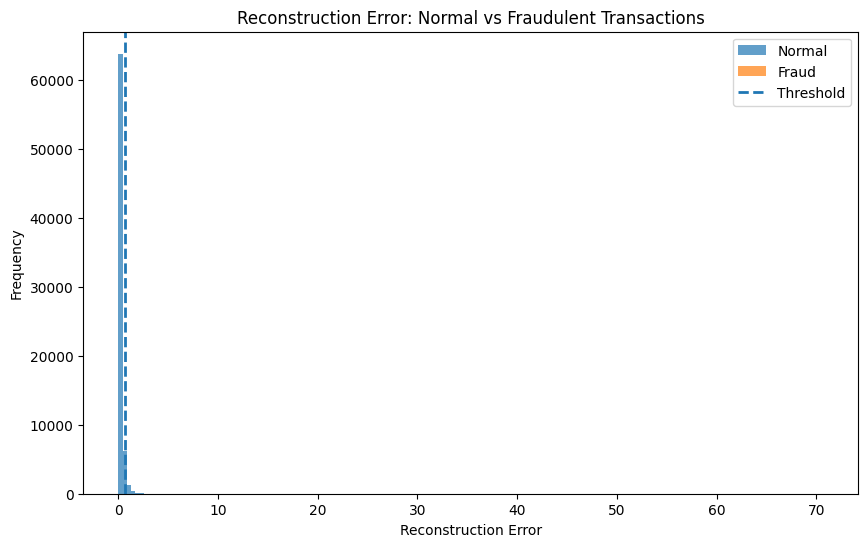

In [24]:
# ============================================
# 18. ERROR DISTRIBUTION BY CLASS
# ============================================

normal_errors = test_reconstruction_error[
    y_test.values == 0
]

fraud_errors = test_reconstruction_error[
    y_test.values == 1
]

plt.figure(figsize=(10, 6))

plt.hist(
    normal_errors,
    bins=100,
    alpha=0.7,
    label="Normal"
)

plt.hist(
    fraud_errors,
    bins=100,
    alpha=0.7,
    label="Fraud"
)

plt.axvline(
    threshold,
    linestyle="--",
    linewidth=2,
    label="Threshold"
)

plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")

plt.title(
    "Reconstruction Error: Normal vs Fraudulent Transactions"
)

plt.legend()

plt.show()

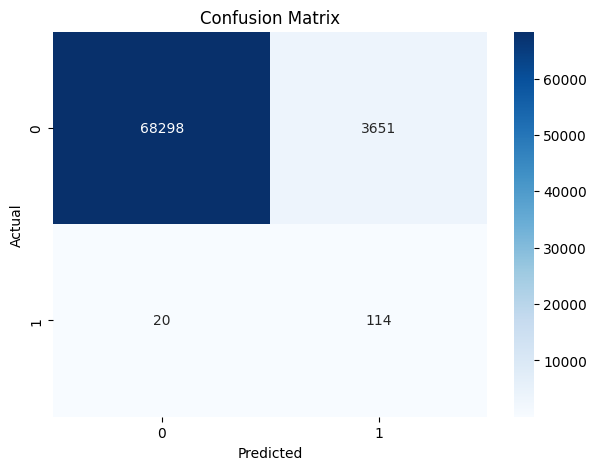

In [25]:
# ============================================
# 19. CONFUSION MATRIX
# ============================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [27]:
# ============================================
# 20. CLASSIFICATION REPORT
# ============================================

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Normal", "Fraud"]
    )
)

              precision    recall  f1-score   support

      Normal       1.00      0.95      0.97     71949
       Fraud       0.03      0.85      0.06       134

    accuracy                           0.95     72083
   macro avg       0.51      0.90      0.52     72083
weighted avg       1.00      0.95      0.97     72083



In [28]:
# ============================================
# 21. EVALUATION METRICS
# ============================================

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    test_reconstruction_error
)

average_precision = average_precision_score(
    y_test,
    test_reconstruction_error
)

print("Precision :", precision)
print("Recall    :", recall)
print("F1 Score  :", f1)
print("ROC-AUC   :", roc_auc)
print("PR-AUC    :", average_precision)

Precision : 0.030278884462151396
Recall    : 0.8507462686567164
F1 Score  : 0.05847653244421647
ROC-AUC   : 0.938151982861824
PR-AUC    : 0.6008262857384451


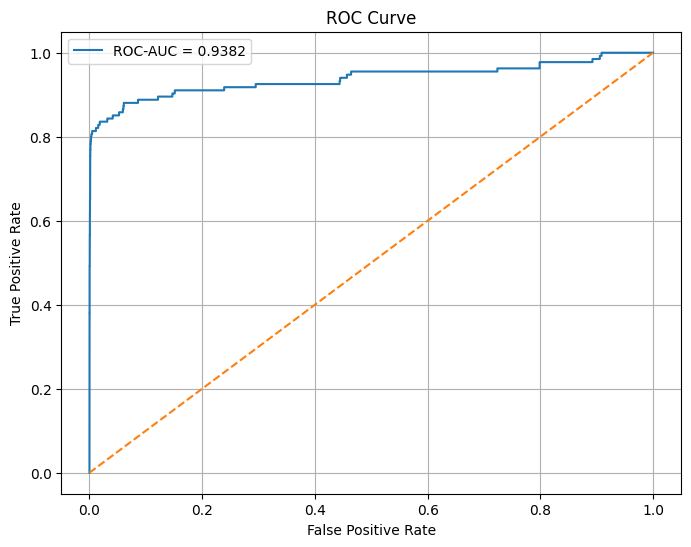

In [29]:
# ============================================
# 22. ROC CURVE
# ============================================

fpr, tpr, thresholds_roc = roc_curve(
    y_test,
    test_reconstruction_error
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {roc_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

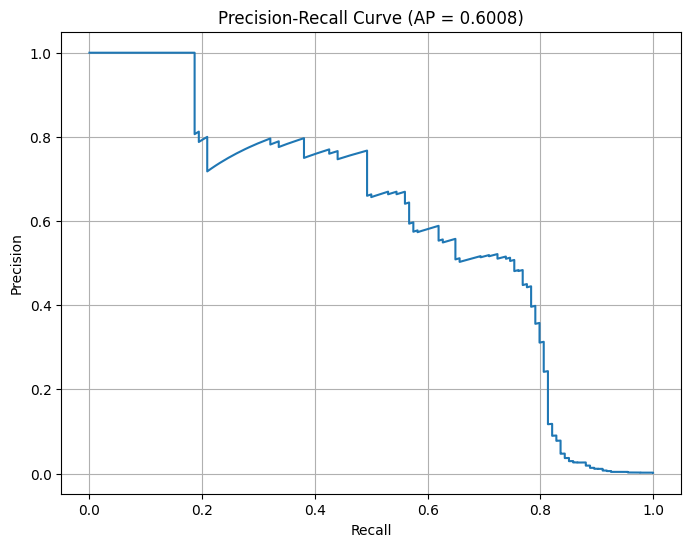

In [30]:
# ============================================
# 23. PRECISION-RECALL CURVE
# ============================================

precision_curve, recall_curve, pr_thresholds = precision_recall_curve(
    y_test,
    test_reconstruction_error
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall_curve,
    precision_curve
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    f"Precision-Recall Curve "
    f"(AP = {average_precision:.4f})"
)

plt.grid(True)

plt.show()

In [31]:
# ============================================
# 24. THRESHOLD OPTIMIZATION USING F1 SCORE
# ============================================

candidate_thresholds = np.percentile(
    test_reconstruction_error,
    np.linspace(80, 99.9, 100)
)

results = []

for t in candidate_thresholds:

    predictions = (
        test_reconstruction_error > t
    ).astype(int)

    precision_value = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall_value = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    f1_value = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    results.append(
        [t, precision_value, recall_value, f1_value]
    )

threshold_results = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1"
    ]
)

threshold_results.head()

,Threshold,Precision,Recall,F1
0,0.299435,0.008462,0.910448,0.016769
1,0.301471,0.008548,0.910448,0.016937
2,0.303677,0.008636,0.910448,0.017110
3,0.305886,0.008726,0.910448,0.017285
4,0.308208,0.008817,0.910448,0.017465


In [32]:
best_row = threshold_results.loc[
    threshold_results["F1"].idxmax()
]

best_threshold = best_row["Threshold"]

print("Best Threshold:", best_threshold)
print("Precision:", best_row["Precision"])
print("Recall:", best_row["Recall"])
print("F1 Score:", best_row["F1"])

Best Threshold: 3.3334462786304275
Precision: 0.47465437788018433
Recall: 0.7686567164179104
F1 Score: 0.5868945868945868


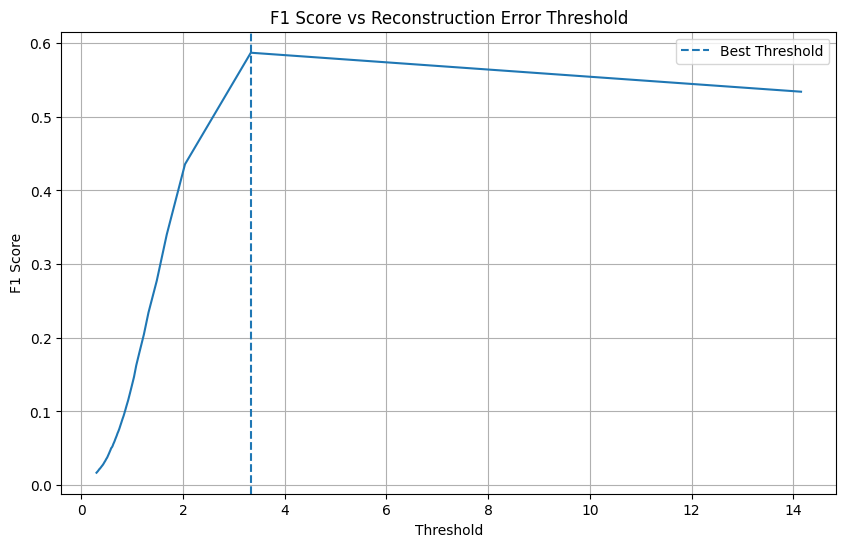

In [33]:
# ============================================
# 25. F1 SCORE VS THRESHOLD
# ============================================

plt.figure(figsize=(10, 6))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F1"]
)

plt.axvline(
    best_threshold,
    linestyle="--",
    label="Best Threshold"
)

plt.xlabel("Threshold")
plt.ylabel("F1 Score")

plt.title("F1 Score vs Reconstruction Error Threshold")

plt.legend()

plt.grid(True)

plt.show()

In [34]:
# ============================================
# 26. FINAL ANOMALY PREDICTIONS
# ============================================

final_predictions = (
    test_reconstruction_error > best_threshold
).astype(int)

print(
    classification_report(
        y_test,
        final_predictions,
        target_names=["Normal", "Fraud"]
    )
)

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     71949
       Fraud       0.47      0.77      0.59       134

    accuracy                           1.00     72083
   macro avg       0.74      0.88      0.79     72083
weighted avg       1.00      1.00      1.00     72083



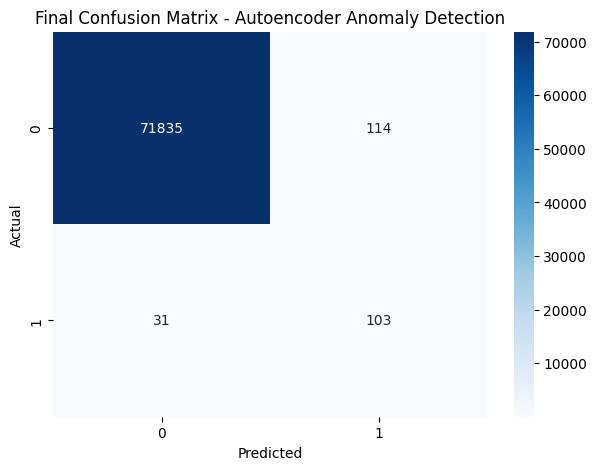

In [35]:
# ============================================
# 27. FINAL CONFUSION MATRIX
# ============================================

final_cm = confusion_matrix(
    y_test,
    final_predictions
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "Final Confusion Matrix - Autoencoder Anomaly Detection"
)

plt.show()

In [36]:
# ============================================
# 28. RESULTS DATAFRAME
# ============================================

results_df = pd.DataFrame({
    "Actual_Class": y_test.values,
    "Reconstruction_Error": test_reconstruction_error,
    "Predicted_Class": final_predictions
})

results_df["Prediction"] = results_df[
    "Predicted_Class"
].map({
    0: "Normal",
    1: "Anomaly"
})

results_df.head(20)

,Actual_Class,Reconstruction_Error,Predicted_Class,Prediction
0,0.0,0.140669,0,Normal
1,0.0,0.250780,0,Normal
2,0.0,0.014918,0,Normal
3,0.0,0.098508,0,Normal
4,0.0,0.247439,0,Normal
5,0.0,0.218200,0,Normal
6,0.0,0.116594,0,Normal
7,0.0,0.410493,0,Normal
8,0.0,0.163775,0,Normal
9,0.0,0.192504,0,Normal


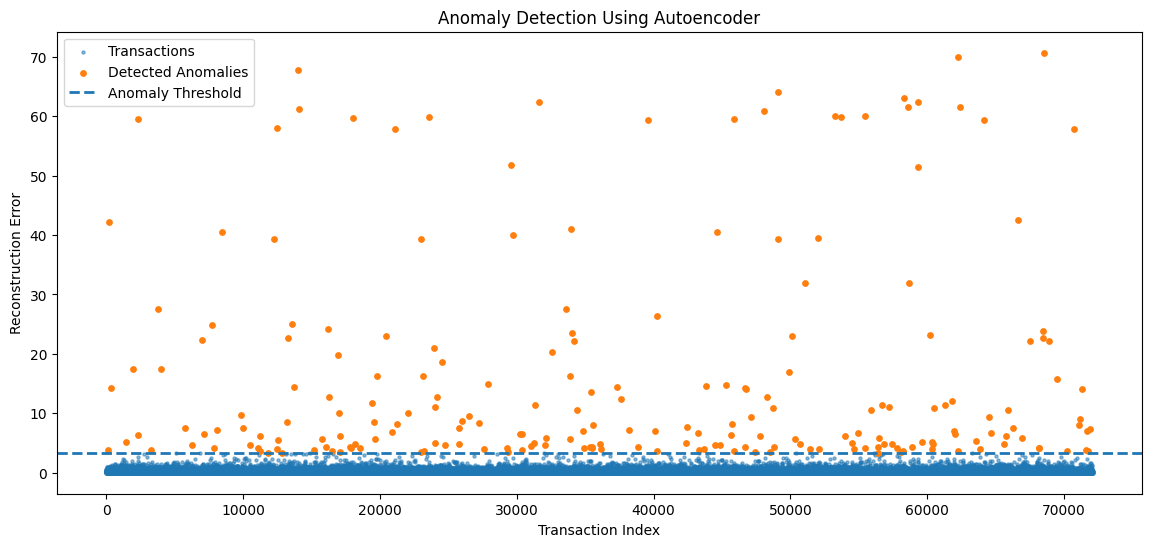

In [37]:
# ============================================
# 29. VISUALIZE ANOMALIES
# ============================================

plt.figure(figsize=(14, 6))

plt.scatter(
    range(len(test_reconstruction_error)),
    test_reconstruction_error,
    s=5,
    alpha=0.5,
    label="Transactions"
)

anomaly_indices = np.where(
    final_predictions == 1
)[0]

plt.scatter(
    anomaly_indices,
    test_reconstruction_error[anomaly_indices],
    s=15,
    label="Detected Anomalies"
)

plt.axhline(
    best_threshold,
    linestyle="--",
    linewidth=2,
    label="Anomaly Threshold"
)

plt.xlabel("Transaction Index")
plt.ylabel("Reconstruction Error")

plt.title(
    "Anomaly Detection Using Autoencoder"
)

plt.legend()

plt.show()

In [39]:
# ============================================
# 30. SAVE MODEL
# ============================================

autoencoder.save("autoencoder_anomaly_detection.keras")

print("Model saved successfully.")

Model saved successfully.


In [40]:
import joblib

joblib.dump(
    scaler,
    "scaler.pkl"
)

print("Scaler saved successfully.")

Scaler saved successfully.


In [41]:
from google.colab import files

files.download(
    "autoencoder_anomaly_detection.keras"
)

files.download(
    "scaler.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [42]:
# ============================================
# 31. EXTRACT LATENT REPRESENTATIONS
# ============================================

encoder_model = Model(
    inputs=autoencoder.input,
    outputs=autoencoder.get_layer("latent_space").output
)

latent_features = encoder_model.predict(
    X_test,
    verbose=0
)

print("Original feature dimension:",
      X_test.shape[1])

print("Latent feature dimension:",
      latent_features.shape[1])

Original feature dimension: 30
Latent feature dimension: 8


In [43]:
# ============================================
# 31. EXTRACT LATENT REPRESENTATIONS
# ============================================

encoder_model = Model(
    inputs=autoencoder.input,
    outputs=autoencoder.get_layer("latent_space").output
)

latent_features = encoder_model.predict(
    X_test,
    verbose=0
)

print("Original feature dimension:",
      X_test.shape[1])

print("Latent feature dimension:",
      latent_features.shape[1])

Original feature dimension: 30
Latent feature dimension: 8
